In [1]:
# =====================================
# Cell 1 - Load Transformer & Test Data
# =====================================

import numpy as np
import tensorflow as tf

# Load the saved Transformer model
model = tf.keras.models.load_model("../models/best_transformer_v2.keras")

# Load test dataset
DATA_PATH = "../dataset/training"

X_test = np.load(f"{DATA_PATH}/X_test.npy")
y_test = np.load(f"{DATA_PATH}/y_test.npy")

print("✅ Transformer model loaded successfully!")
print("Test data shape :", X_test.shape)
print("Test labels shape:", y_test.shape)

✅ Transformer model loaded successfully!
Test data shape : (487, 154, 63)
Test labels shape: (487,)


In [2]:
# =====================================
# Cell 2 - Normalize Test Data
# =====================================

# Load training data only to calculate normalization statistics
X_train = np.load("../dataset/training/X_train.npy")

# Calculate training mean and standard deviation
train_mean = np.mean(X_train)
train_std = np.std(X_train) + 1e-8

# Normalize the test set
X_test = (X_test - train_mean) / train_std

print("✅ Test data normalized successfully!")
print("Mean:", np.mean(X_test))
print("Std :", np.std(X_test))

✅ Test data normalized successfully!
Mean: 0.0033953818
Std : 1.0057045


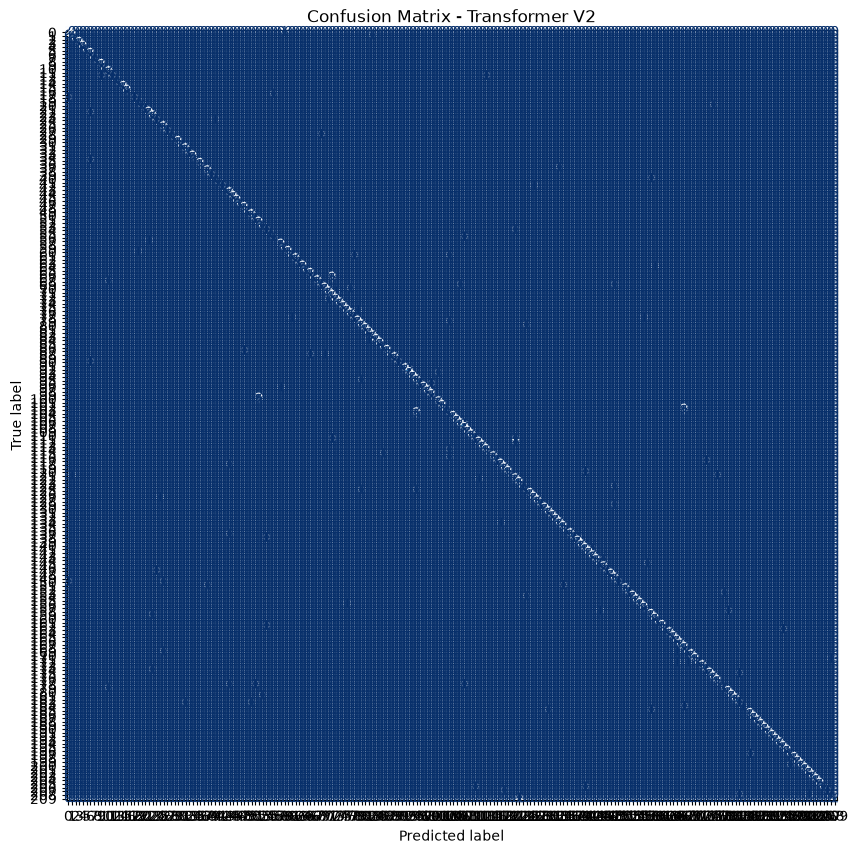

✅ Confusion matrix generated!


In [3]:
# =====================================
# Cell 3 - Confusion Matrix
# =====================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict test labels
y_pred = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - Transformer V2")
plt.show()

print("✅ Confusion matrix generated!")

In [4]:
# =====================================
# Cell 4 - Classification Report
# =====================================

from sklearn.metrics import classification_report, accuracy_score

print("========== CLASSIFICATION REPORT ==========\n")

print(classification_report(y_test, y_pred, digits=3))

overall_acc = accuracy_score(y_test, y_pred)

print("\n===========================================")
print(f"Overall Accuracy : {overall_acc*100:.2f}%")
print("===========================================")

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0      0.500     0.667     0.571         3
           1      0.667     0.667     0.667         3
           2      1.000     1.000     1.000         1
           3      1.000     1.000     1.000         3
           4      1.000     1.000     1.000         3
           5      1.000     1.000     1.000         1
           6      0.500     1.000     0.667         3
           7      1.000     1.000     1.000         1
           8      1.000     1.000     1.000         1
           9      0.750     1.000     0.857         3
          10      1.000     1.000     1.000         1
          11      0.600     1.000     0.750         3
          12      1.000     0.333     0.500         3
          13      1.000     1.000     1.000         1
          14      1.000     1.000     1.000         1
          15      1.000     1.000     1.000         3
          16      1.000     1.000   

c:\Users\palak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\palak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\palak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

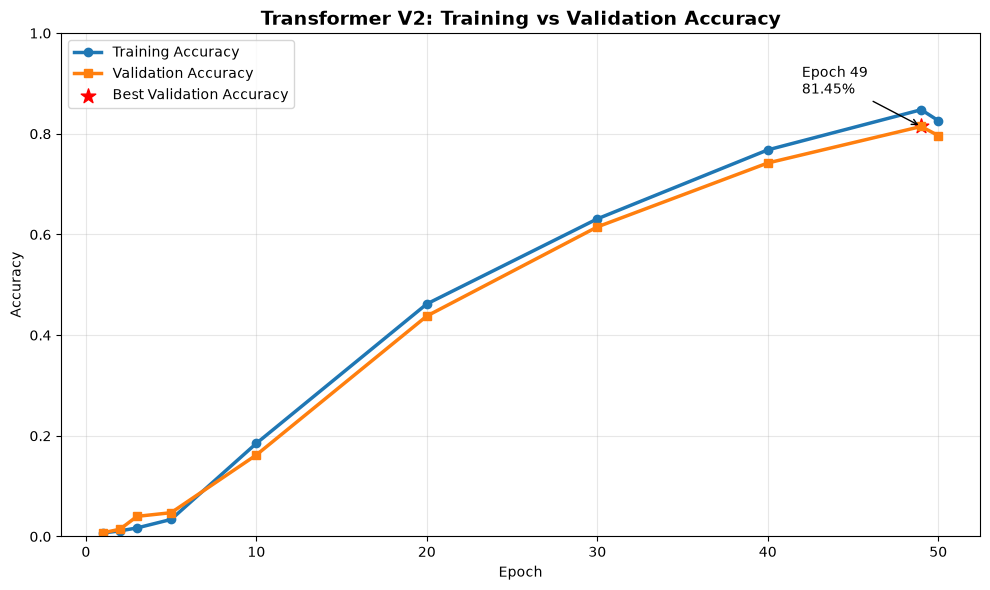

In [10]:
import matplotlib.pyplot as plt

epochs = [1,2,3,5,10,20,30,40,49,50]

train_acc = [0.0070,0.0112,0.0170,0.0339,0.1850,
             0.4620,0.6310,0.7680,0.8478,0.8262]

val_acc = [0.0073,0.0145,0.0400,0.0473,0.1620,
           0.4380,0.6150,0.7420,0.8145,0.7964]

plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc, marker="o", linewidth=2.5,
         label="Training Accuracy")

plt.plot(epochs, val_acc, marker="s", linewidth=2.5,
         label="Validation Accuracy")

# Highlight best validation accuracy
best_epoch = 49
best_acc = 0.8145

plt.scatter(best_epoch, best_acc, s=120, marker="*", color="red",
            label="Best Validation Accuracy")
plt.annotate("Epoch 49\n81.45%",
             xy=(49, 0.8145),
             xytext=(42, 0.88),
             arrowprops=dict(arrowstyle="->"))
plt.title("Transformer V2: Training vs Validation Accuracy",
          fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()